This notebook is for analysis of the micro1 controlled experiment.

We have two pipelines which result in two datasets(AI and Manual). The first pipeline is those candidates who were prompted to complete an AI led interview. Only 6121 out of 25481 candidates completed the interview. The second pipeline is those candidates who were not prompted to complete an AI led interview but instead were sorted by an AI ranking system (not novel) and then screened by a human. 11298 candidates were ranked and the top candidates were selected for the manual screening by ah human.
1. AI pipeline
2. Manual pipeline

We have three datasets:
1. AI dataset
2. Manual (resume)screening dataset
3. Top candidates dataset: these are the top candidates from both the AI and manual datasets that were interviewed by a human.

In [3]:
pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [5]:
AI_applicants_df = pd.read_csv("job_101(AI)_w_age_gender.csv")
manual_screening_applicants_df = pd.read_csv("job_110(Manual)_w_age_gender.csv")
top_candidates_interviewed = pd.read_csv("top_candidates_interviewed.csv")

### The below shows there are duplicates in the AI and manual datasets

In [6]:
# check to see how many emails in AI_applicants_df are in the manual_screening_applicants_df
AI_applicants_df['email_id'].isin(manual_screening_applicants_df['email_id']).sum()

2335

In [7]:
# Get the list of email_ids that are in both AI_applicants_df and manual_screening_applicants_df
common_emails = AI_applicants_df[AI_applicants_df['email_id'].isin(manual_screening_applicants_df['email_id'])]['email_id']

print(f"Number of emails that appear in both datasets: {len(common_emails)}")

# Display the first few common emails
print("\nSample of common emails:")
print(common_emails.head())

# Count unique emails in the intersection
unique_common_emails = common_emails.drop_duplicates()
print(f"\nNumber of unique emails in both datasets: {len(unique_common_emails)}")

# Save the list of common emails to a variable for further analysis
common_email_list = unique_common_emails.tolist()
# Load the top candidates dataset

# Check which emails from the common_email_list are also in the top_candidates_interviewed dataset
common_emails_in_top_candidates = [email for email in common_email_list if email in top_candidates_interviewed['email_id'].values]

print(f"Number of common emails that are also in top_candidates_interviewed: {len(common_emails_in_top_candidates)}")

# Display a few examples if any exist
if common_emails_in_top_candidates:
    print("\nSample of common emails that were interviewed:")
    print(common_emails_in_top_candidates[:5])  # Show first 5 examples
else:
    print("\nNo common emails were found in the top_candidates_interviewed dataset.")

# Calculate the percentage of common emails that made it to interviews
percentage = (len(common_emails_in_top_candidates) / top_candidates_interviewed.shape[0]) * 100 if top_candidates_interviewed.shape[0] > 0 else 0
print(f"\nPercentage of common emails that made it to interviews: {percentage:.2f}%")


Number of emails that appear in both datasets: 2335

Sample of common emails:
14    fdeveloperofficial@gmail.com
34              rthenage@gmail.com
37           moizali2577@gmail.com
51           asseressa65@gmail.com
83        matheusv090807@gmail.com
Name: email_id, dtype: object

Number of unique emails in both datasets: 2335
Number of common emails that are also in top_candidates_interviewed: 18

Sample of common emails that were interviewed:
['mohdaqib129@gmail.com', 'dhanarajbhaskar690@gmail.com', 'n.mohansai53@gmail.com', 'evcharan6519@gmail.com', 'it.divyanshi@gmail.com']

Percentage of common emails that made it to interviews: 21.18%


In [8]:
# Create a list of all email_ids that are in both AI and manual screening datasets
duplicate_emails = list(set(AI_applicants_df['email_id']).intersection(set(manual_screening_applicants_df['email_id'])))
print(f"Number of duplicate email_ids between AI and manual screening datasets: {len(duplicate_emails)}")

# Remove rows with duplicate emails from AI applicants dataframe
ai_applicants_clean = AI_applicants_df[~AI_applicants_df['email_id'].isin(duplicate_emails)]
print(f"AI applicants dataframe shape after removing duplicates: {ai_applicants_clean.shape}")

# Remove rows with duplicate emails from manual screening applicants dataframe
manual_screening_clean = manual_screening_applicants_df[~manual_screening_applicants_df['email_id'].isin(duplicate_emails)]
print(f"Manual screening dataframe shape after removing duplicates: {manual_screening_clean.shape}")

# Remove rows with duplicate emails from top candidates interviewed dataframe
top_candidates_clean = top_candidates_interviewed[~top_candidates_interviewed['email_id'].isin(duplicate_emails)]
print(f"Top candidates dataframe shape after removing duplicates: {top_candidates_clean.shape}")

# Assign cleaned datasets to new variables for analysis
ai_applicants_df_clean = ai_applicants_clean
manual_screening_applicants_df_clean = manual_screening_clean
top_candidates_interviewed_clean = top_candidates_clean

# Calculate pass rate for AI + Human Interview candidates using cleaned data
ai_human_candidates = top_candidates_interviewed_clean[top_candidates_interviewed_clean['Interview Type'] == 'AI + Human Interview']
ai_human_pass_count = sum(ai_human_candidates['Result'] == 'Pass')
ai_human_fail_count = sum(ai_human_candidates['Result'] == 'Fail')
ai_human_pass_rate = (ai_human_pass_count / len(ai_human_candidates)) * 100 if len(ai_human_candidates) > 0 else 0
print(f"\nPass rate for candidates with 'AI + Human Interview': {ai_human_pass_rate:.2f}%")

# Calculate pass rate for only Human Interview candidates using cleaned data
human_only_candidates = top_candidates_interviewed_clean[top_candidates_interviewed_clean['Interview Type'] == 'only Human interview']
human_only_pass_count = sum(human_only_candidates['Result'] == 'Pass')
human_only_fail_count = sum(human_only_candidates['Result'] == 'Fail')
human_only_pass_rate = (human_only_pass_count / len(human_only_candidates)) * 100 if len(human_only_candidates) > 0 else 0
print(f"Pass rate for candidates with 'only Human interview': {human_only_pass_rate:.2f}%")

# Perform a statistical test to determine if the difference in pass rates is statistically significant
import scipy.stats as stats
import numpy as np

# Extract the data for the statistical test from cleaned datasets
ai_human_passes = ai_human_pass_count
ai_human_fails = ai_human_fail_count

human_only_passes = human_only_pass_count
human_only_fails = human_only_fail_count

# Create a contingency table
contingency_table = np.array([
    [ai_human_passes, ai_human_fails],
    [human_only_passes, human_only_fails]
])

print("\nContingency Table (using cleaned data):")
print(f"                    | Passes | Fails | Total")
print(f"AI + Human Interview | {ai_human_passes:6d} | {ai_human_fails:5d} | {ai_human_passes + ai_human_fails:5d}")
print(f"Only Human Interview | {human_only_passes:6d} | {human_only_fails:5d} | {human_only_passes + human_only_fails:5d}")

# Perform Chi-square test on cleaned data
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

# Print the results
print(f"\nChi-square test results (using cleaned data):")
print(f"Chi-square value: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"\nThe p-value ({p_value:.4f}) is less than the significance level ({alpha}), so we reject the null hypothesis.")
    print("There is a statistically significant difference in pass rates between the two interview types.")
else:
    print(f"\nThe p-value ({p_value:.4f}) is greater than the significance level ({alpha}), so we fail to reject the null hypothesis.")
    print("There is not enough evidence to conclude a statistically significant difference in pass rates between the two interview types.")

# Calculate the effect size (Cramer's V) using cleaned data
n = contingency_table.sum()
cramer_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
print(f"\nEffect size (Cramer's V): {cramer_v:.4f}")

# Interpret the effect size
if cramer_v < 0.1:
    effect_interpretation = "negligible"
elif cramer_v < 0.3:
    effect_interpretation = "small"
elif cramer_v < 0.5:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"
    
print(f"This represents a {effect_interpretation} effect size.")


Number of duplicate email_ids between AI and manual screening datasets: 2335
AI applicants dataframe shape after removing duplicates: (23208, 18)
Manual screening dataframe shape after removing duplicates: (8960, 19)
Top candidates dataframe shape after removing duplicates: (67, 21)

Pass rate for candidates with 'AI + Human Interview': 53.12%
Pass rate for candidates with 'only Human interview': 28.57%

Contingency Table (using cleaned data):
                    | Passes | Fails | Total
AI + Human Interview |     17 |    11 |    28
Only Human Interview |     10 |    24 |    34

Chi-square test results (using cleaned data):
Chi-square value: 4.9130
p-value: 0.0267
Degrees of freedom: 1

The p-value (0.0267) is less than the significance level (0.05), so we reject the null hypothesis.
There is a statistically significant difference in pass rates between the two interview types.

Effect size (Cramer's V): 0.2815
This represents a small effect size.


#### Once we removed the duplicates, we can still colculde a statistically significant difference between the two interview types. ^^^

In [9]:
# These are our new cleaned datasets with no duplicates


print(ai_applicants_clean.shape[0])
print(manual_screening_clean.shape[0])
print(top_candidates_clean.shape[0])

#Reassign the cleaned datasets to the original variables to conduct the demographicanalysis on the cleaned datasets

ai_applicants_df = ai_applicants_clean
manual_screening_applicants_df = manual_screening_clean
top_candidates_interviewed = top_candidates_clean

23208
8960
67


In [10]:
# Count the number of email_ids that are in top_candidates_interviewed that are also in ai_applicants_df
ai_emails_in_top_candidates = top_candidates_interviewed['email_id'].isin(ai_applicants_df['email_id']).sum()
print(f"Number of email_ids in top_candidates_interviewed that are also in ai_applicants_df: {ai_emails_in_top_candidates}")

# Count the number of email_ids that are in top_candidates_interviewed that are also in manual_screening_applicants_df
manual_emails_in_top_candidates = top_candidates_interviewed['email_id'].isin(manual_screening_applicants_df['email_id']).sum()
print(f"Number of email_ids in top_candidates_interviewed that are also in manual_screening_applicants_df: {manual_emails_in_top_candidates}")


Number of email_ids in top_candidates_interviewed that are also in ai_applicants_df: 27
Number of email_ids in top_candidates_interviewed that are also in manual_screening_applicants_df: 35


In [11]:
ai_df_unique = AI_applicants_df.drop_duplicates(subset=['_client_job_id'], keep='first')
ai_df_unique.head()

,first_name,last_name,email_id,_client_job_id,country_code,job_application_id,years_of_exp,is_completed,vetting_creation_date,vetting_completed_date,is_deleted,status,developer_location,is_certified_developer,is_passed,education,gender,age
0,Lyuben,Tenekedzhiev,lyuben.tenekedjiev@gmail.com,7ab84d91-00ca-460f-ac82-ccad63fb306c,AE,2b85d400-3fd9-4747-af25-314bfdd9220c,4.7,1.0,2025-01-31 14:48:27,2025-01-31 15:31:05,0.0,active,United Arab Emirates,0.0,False,[],Male,27


In [12]:
manual_df_unique = manual_screening_applicants_df.drop_duplicates(subset=['_client_job_id'], keep='first')
manual_df_unique.head()

,first_name,last_name,email_id,_client_job_id,country_code,job_application_id,years_of_experience,years_of_exp,is_completed,vetting_creation_date,vetting_completed_date,is_deleted,status,developer_location,is_certified_developer,is_passed,education,gender,age
1,Rohit,Sharma,rsharma68368@gmail.com,d1e2b62f-4954-49c6-931c-ba76aa4741e1,IN,5ef3d7b1-d4ea-435a-b453-a9165f6f4413,1.5,1.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,"[{""major"": ""Computer Science"", ""degree"": ""B.Sc...",Male,23


In [13]:
AI_applicants_df.shape[0]


25543

In [14]:
# Count the number of candidates in AI_applicants_df that have a non-NULL vetting_completed_date
ai_candidates_with_completed_vetting = AI_applicants_df.dropna(subset=['vetting_completed_date']).shape[0]
print(f"Number of candidates in AI_applicants_df with completed vetting: {ai_candidates_with_completed_vetting}")


Number of candidates in AI_applicants_df with completed vetting: 6400


Candidates with completed vetting: 6400
Candidates without completed vetting: 19143

--- Age Comparison ---
Completed vetting - Mean age: 24.74, Median: 24.0
Incomplete vetting - Mean age: 25.03, Median: 24.0
Age difference p-value: 0.0000
The age difference is highly statistically significant (p < 0.001)

--- Age Group Analysis ---
           completed  incomplete  total  completion_rate
age_group                                               
Under 25        3604       10102  13706        26.295053
25-34           2548        8232  10780        23.636364
35-44            219         705    924        23.701299
45+               29         104    133        21.804511

Completion rates by age group:
Under 25: 26.30%
25-34: 23.64%
35-44: 23.70%
45+: 21.80%

Age group distribution chi-square p-value: 0.0000
The age group distribution difference is highly statistically significant (p < 0.001)

--- Gender Comparison ---
Completed vetting - Female percentage: 21.83%
Incomplete vetting - Fem

/var/folders/55/zxlszwyx6ts_bpf6cjjywywr0000gn/T/ipykernel_1012/3705660457.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ai_completed_vetting['age_group'] = ai_completed_vetting['age'].apply(lambda x: categorize_age(x) if not pd.isna(x) else np.nan)
/var/folders/55/zxlszwyx6ts_bpf6cjjywywr0000gn/T/ipykernel_1012/3705660457.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ai_incomplete_vetting['age_group'] = ai_incomplete_vetting['age'].apply(lambda x: categorize_age(x) if not pd.isna(x) else np.n

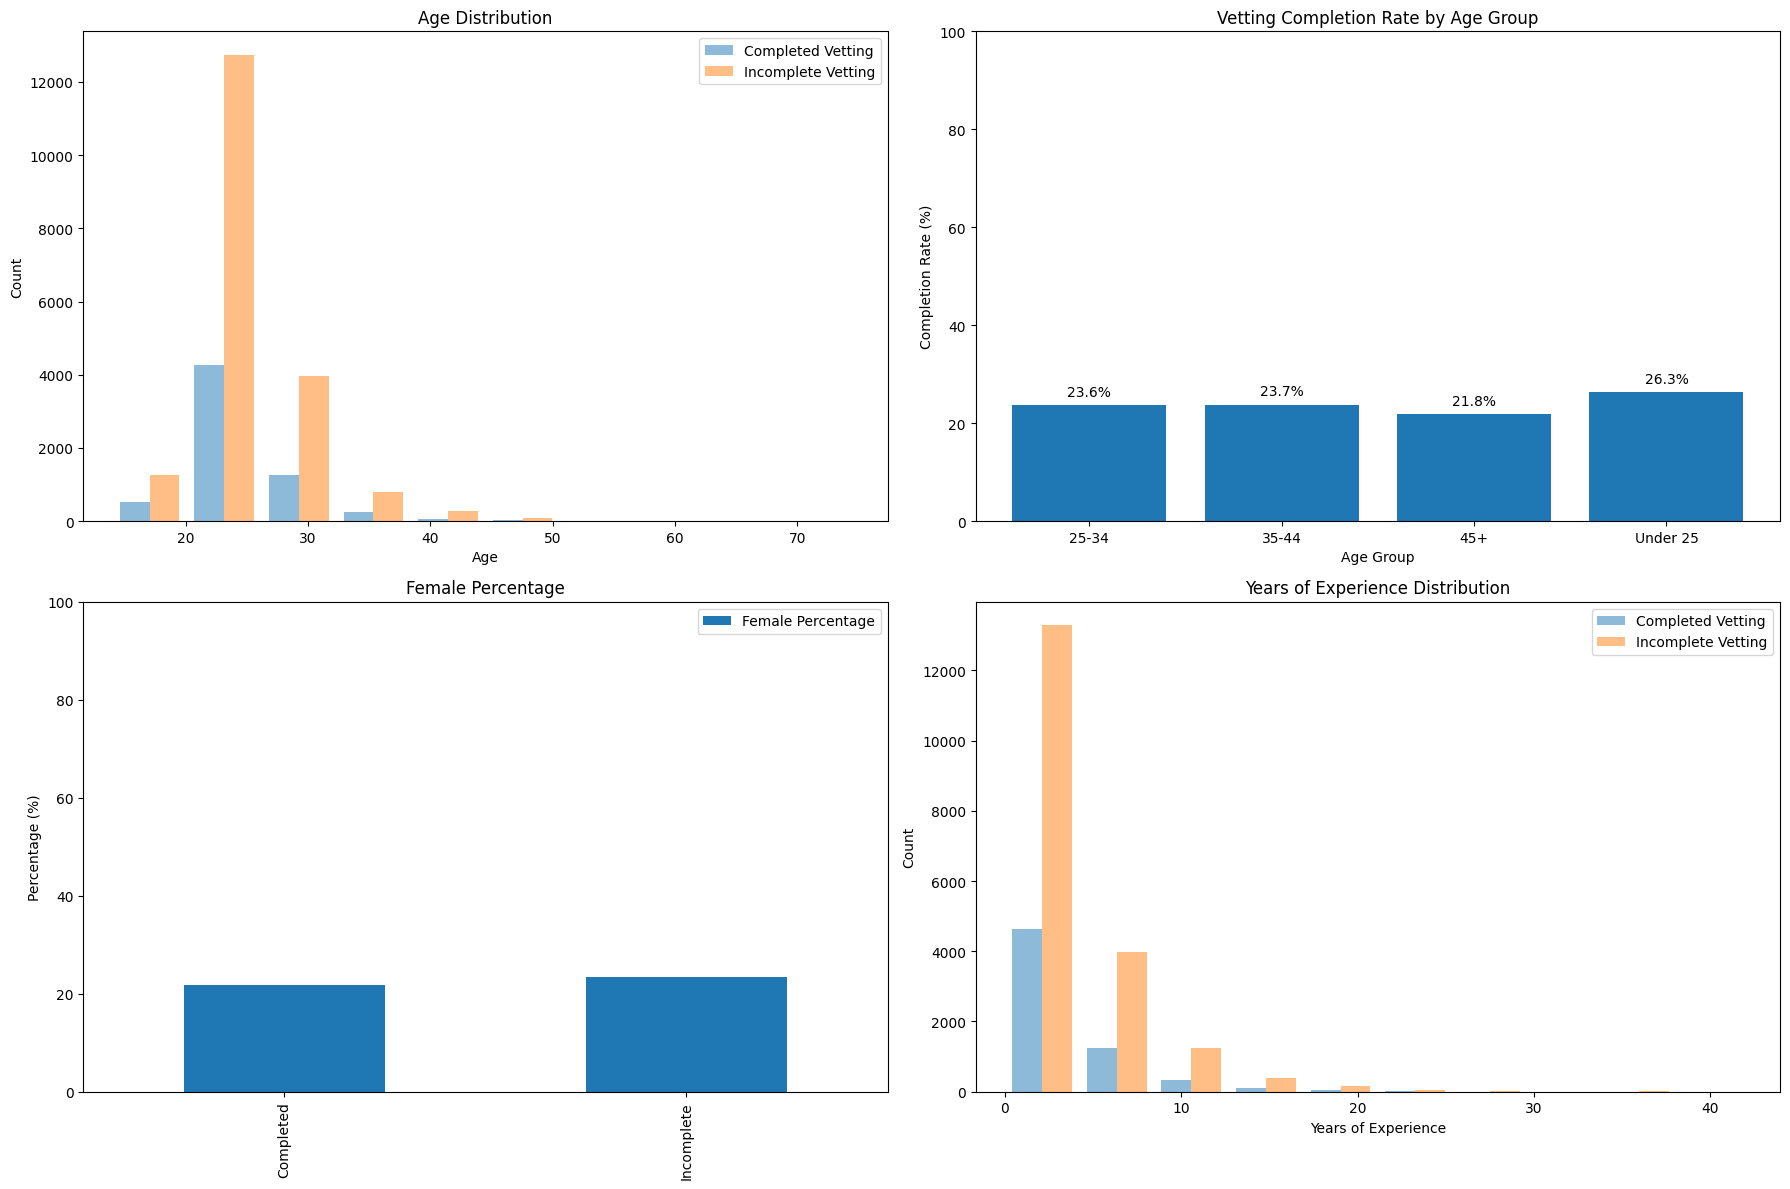

In [15]:
# Demographic analysis comparing candidates with completed vetting vs those without

# Split the AI applicants into two groups
ai_completed_vetting = AI_applicants_df.dropna(subset=['vetting_completed_date'])
ai_incomplete_vetting = AI_applicants_df[AI_applicants_df['vetting_completed_date'].isna()]

print(f"Candidates with completed vetting: {ai_completed_vetting.shape[0]}")
print(f"Candidates without completed vetting: {ai_incomplete_vetting.shape[0]}")

# Age comparison
print("\n--- Age Comparison ---")
completed_age = ai_completed_vetting['age'].dropna()
incomplete_age = ai_incomplete_vetting['age'].dropna()

print(f"Completed vetting - Mean age: {completed_age.mean():.2f}, Median: {completed_age.median()}")
print(f"Incomplete vetting - Mean age: {incomplete_age.mean():.2f}, Median: {incomplete_age.median()}")

# Perform t-test for age
from scipy import stats
age_ttest = stats.ttest_ind(completed_age, incomplete_age, equal_var=False, nan_policy='omit')
print(f"Age difference p-value: {age_ttest.pvalue:.4f}")
if age_ttest.pvalue < 0.001:
    print("The age difference is highly statistically significant (p < 0.001)")
elif age_ttest.pvalue < 0.01:
    print("The age difference is very statistically significant (p < 0.01)")
elif age_ttest.pvalue < 0.05:
    print("The age difference is statistically significant (p < 0.05)")
else:
    print("The age difference is not statistically significant (p ≥ 0.05)")

# Age group analysis
print("\n--- Age Group Analysis ---")
# Create age groups
def categorize_age(age):
    if age < 25:
        return "Under 25"
    elif age < 35:
        return "25-34"
    elif age < 45:
        return "35-44"
    else:
        return "45+"

# Apply age grouping to both datasets
ai_completed_vetting['age_group'] = ai_completed_vetting['age'].apply(lambda x: categorize_age(x) if not pd.isna(x) else np.nan)
ai_incomplete_vetting['age_group'] = ai_incomplete_vetting['age'].apply(lambda x: categorize_age(x) if not pd.isna(x) else np.nan)

# Calculate completion rates by age group
age_group_counts = pd.DataFrame({
    'completed': ai_completed_vetting['age_group'].value_counts(),
    'incomplete': ai_incomplete_vetting['age_group'].value_counts()
})
age_group_counts['total'] = age_group_counts['completed'] + age_group_counts['incomplete']
age_group_counts['completion_rate'] = age_group_counts['completed'] / age_group_counts['total'] * 100

print(age_group_counts)
print("\nCompletion rates by age group:")
for age_group in age_group_counts.index:
    print(f"{age_group}: {age_group_counts.loc[age_group, 'completion_rate']:.2f}%")

# Chi-square test for age groups
age_contingency = age_group_counts[['completed', 'incomplete']].values
age_chi2, age_p, _, _ = stats.chi2_contingency(age_contingency)
print(f"\nAge group distribution chi-square p-value: {age_p:.4f}")
if age_p < 0.001:
    print("The age group distribution difference is highly statistically significant (p < 0.001)")
elif age_p < 0.01:
    print("The age group distribution difference is very statistically significant (p < 0.01)")
elif age_p < 0.05:
    print("The age group distribution difference is statistically significant (p < 0.05)")
else:
    print("The age group distribution difference is not statistically significant (p ≥ 0.05)")

# Gender comparison
print("\n--- Gender Comparison ---")
# Calculate percentage of female applicants in each group
completed_female_pct = (ai_completed_vetting['gender'] == 'Female').mean() * 100
incomplete_female_pct = (ai_incomplete_vetting['gender'] == 'Female').mean() * 100

print(f"Completed vetting - Female percentage: {completed_female_pct:.2f}%")
print(f"Incomplete vetting - Female percentage: {incomplete_female_pct:.2f}%")

# Chi-square test for gender
completed_gender_table = ai_completed_vetting['gender'].value_counts()
incomplete_gender_table = ai_incomplete_vetting['gender'].value_counts()

# Ensure both tables have the same categories
all_genders = set(completed_gender_table.index) | set(incomplete_gender_table.index)
gender_contingency = pd.DataFrame({
    'Completed': [completed_gender_table.get(gender, 0) for gender in all_genders],
    'Incomplete': [incomplete_gender_table.get(gender, 0) for gender in all_genders]
}, index=list(all_genders))

gender_chi2, gender_p, _, _ = stats.chi2_contingency(gender_contingency)
print(f"Gender distribution difference p-value: {gender_p:.4f}")
if gender_p < 0.001:
    print("The gender distribution difference is highly statistically significant (p < 0.001)")
elif gender_p < 0.01:
    print("The gender distribution difference is very statistically significant (p < 0.01)")
elif gender_p < 0.05:
    print("The gender distribution difference is statistically significant (p < 0.05)")
else:
    print("The gender distribution difference is not statistically significant (p ≥ 0.05)")

# Years of experience comparison
print("\n--- Years of Experience Comparison ---")
completed_exp = ai_completed_vetting['years_of_exp'].dropna()
incomplete_exp = ai_incomplete_vetting['years_of_exp'].dropna()

print(f"Completed vetting - Mean years of experience: {completed_exp.mean():.2f}, Median: {completed_exp.median():.2f}")
print(f"Incomplete vetting - Mean years of experience: {incomplete_exp.mean():.2f}, Median: {incomplete_exp.median():.2f}")

# Perform t-test for years of experience
exp_ttest = stats.ttest_ind(completed_exp, incomplete_exp, equal_var=False, nan_policy='omit')
print(f"Years of experience difference p-value: {exp_ttest.pvalue:.4f}")
if exp_ttest.pvalue < 0.001:
    print("The years of experience difference is highly statistically significant (p < 0.001)")
elif exp_ttest.pvalue < 0.01:
    print("The years of experience difference is very statistically significant (p < 0.01)")
elif exp_ttest.pvalue < 0.05:
    print("The years of experience difference is statistically significant (p < 0.05)")
else:
    print("The years of experience difference is not statistically significant (p ≥ 0.05)")

# Visualize the differences
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Age distribution
axes[0, 0].hist([completed_age, incomplete_age], bins=10, alpha=0.5, 
             label=['Completed Vetting', 'Incomplete Vetting'])
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()

# Age group completion rates
age_group_completion = age_group_counts['completion_rate'].sort_index()
axes[0, 1].bar(age_group_completion.index, age_group_completion.values)
axes[0, 1].set_title('Vetting Completion Rate by Age Group')
axes[0, 1].set_xlabel('Age Group')
axes[0, 1].set_ylabel('Completion Rate (%)')
axes[0, 1].set_ylim(0, 100)
for i, v in enumerate(age_group_completion.values):
    axes[0, 1].text(i, v + 2, f"{v:.1f}%", ha='center')

# Gender distribution (female percentage)
gender_df = pd.DataFrame({
    'Female Percentage': [completed_female_pct, incomplete_female_pct]
}, index=['Completed', 'Incomplete'])
gender_df.plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Female Percentage')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].set_ylim(0, 100)

# Years of experience distribution
axes[1, 1].hist([completed_exp, incomplete_exp], bins=10, alpha=0.5,
             label=['Completed Vetting', 'Incomplete Vetting'])
axes[1, 1].set_title('Years of Experience Distribution')
axes[1, 1].set_xlabel('Years of Experience')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


In [16]:
manual_screening_applicants_df.shape[0]

8960

In [17]:
# Count the number of rows with duplicate email_id values
# First, identify which email_ids appear more than once
duplicate_email_ids = AI_applicants_df['email_id'].value_counts()
duplicate_email_ids = duplicate_email_ids[duplicate_email_ids > 1]

# Then, count the total number of rows that have these duplicate email_ids
rows_with_duplicate_emails = AI_applicants_df[AI_applicants_df['email_id'].isin(duplicate_email_ids.index)].shape[0]
rows_with_duplicate_emails




0

In [18]:
# Count the number of rows with duplicate email_id values
# First, identify which email_ids appear more than once
duplicate_email_ids = manual_screening_applicants_df['email_id'].value_counts()
duplicate_email_ids = duplicate_email_ids[duplicate_email_ids > 1]

# Then, count the total number of rows that have these duplicate email_ids
rows_with_duplicate_emails = manual_screening_applicants_df[manual_screening_applicants_df['email_id'].isin(duplicate_email_ids.index)].shape[0]
rows_with_duplicate_emails

0

In [19]:
top_candidates_interviewed.shape[0]


67

### Demographics of the applicants who succeeded and failed the human interview

Gender distribution of candidates who passed:
Gender
Male      88.461538
Female    11.538462
Name: count, dtype: float64


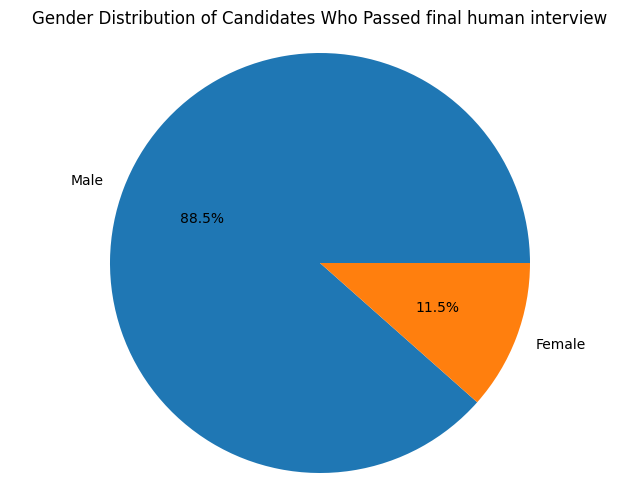

In [20]:
# Filter for passed candidates
passed_candidates = top_candidates_interviewed[top_candidates_interviewed['Result'] == 'Pass']

# Count by gender
gender_counts = passed_candidates['Gender'].value_counts()

# Calculate percentages
gender_percentages = gender_counts / gender_counts.sum() * 100

# Display the results
print("Gender distribution of candidates who passed:")
print(gender_percentages)

# Optional: Create a pie chart visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.pie(gender_percentages, labels=gender_percentages.index, autopct='%1.1f%%')
plt.title('Gender Distribution of Candidates Who Passed final human interview')
plt.axis('equal')
plt.show()


Pass rates by gender:
Result  Pass  Fail  Total  Pass Rate
Gender                              
Female     3     5      8  37.500000
Male      23    30     54  42.592593


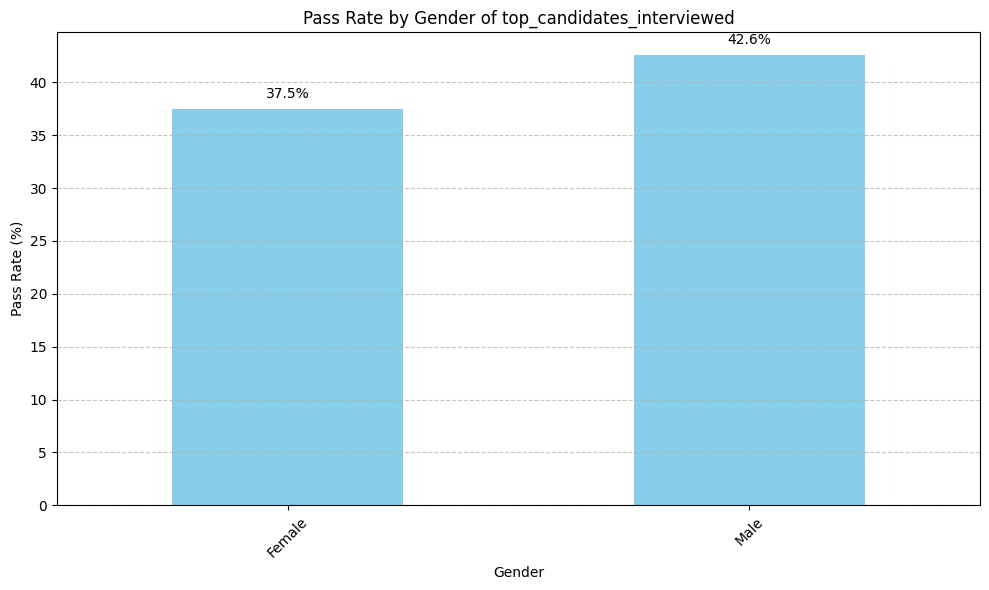


Statistical Significance Test:
Chi-square value: 0.0000
p-value: 1.0000
Degrees of freedom: 1
The difference in pass rates between genders is not statistically significant (p > 0.05).


In [21]:

# Group by gender and result, then count
gender_result_counts = top_candidates_interviewed.groupby(['Gender', 'Result']).size().unstack(fill_value=0)

# Calculate pass rates for each gender
gender_result_counts['Total'] = gender_result_counts.sum(axis=1)
gender_result_counts['Pass Rate'] = gender_result_counts['Pass'] / gender_result_counts['Total'] * 100

# Display the results
print("Pass rates by gender:")
print(gender_result_counts[['Pass', 'Fail', 'Total', 'Pass Rate']])

# Create a bar chart visualization
plt.figure(figsize=(10, 6))
gender_result_counts['Pass Rate'].plot(kind='bar', color='skyblue')
plt.title('Pass Rate by Gender of top_candidates_interviewed')
plt.xlabel('Gender')
plt.ylabel('Pass Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels on top of each bar
for i, rate in enumerate(gender_result_counts['Pass Rate']):
    plt.text(i, rate + 1, f'{rate:.1f}%', ha='center')

plt.tight_layout()
plt.show()

# Statistical significance test
import scipy.stats as stats

# Create a contingency table for chi-square test
contingency_table = gender_result_counts[['Pass', 'Fail']]

# Perform chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("\nStatistical Significance Test:")
print(f"Chi-square value: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"The difference in pass rates between genders is statistically significant (p < {alpha}).")
else:
    print(f"The difference in pass rates between genders is not statistically significant (p > {alpha}).")



Percentage of Women in Different Datasets:
Top candidates interviewed: 11.94% women (8 out of 67)
Manual screening applicants: 22.54% women (2020 out of 8960)
AI applicants: 23.01% women (5877 out of 25543)


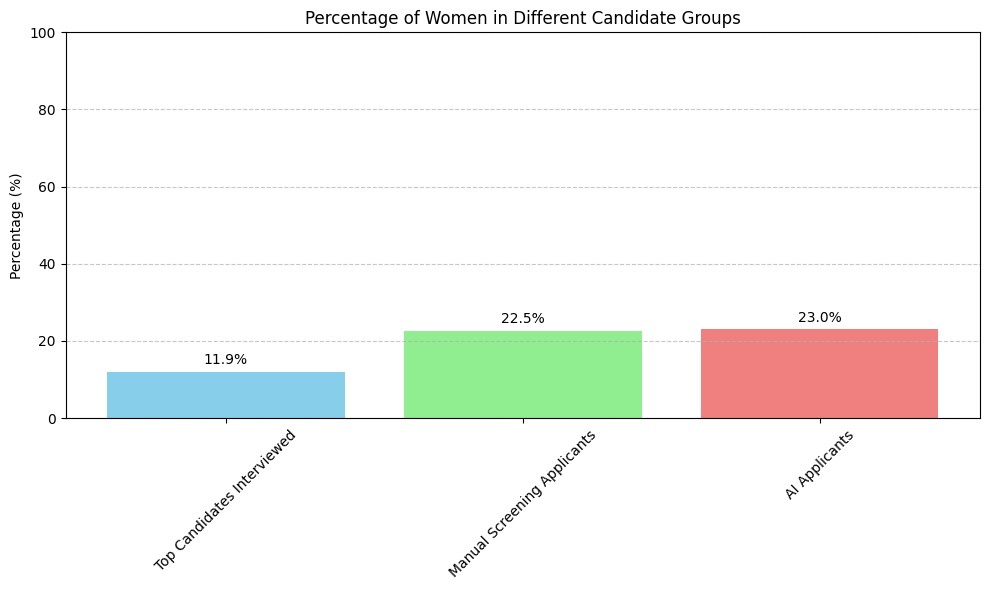


Statistical Significance Tests for Gender Distribution Differences:

Comparing Top Candidates Interviewed vs Manual Screening Applicants:
Chi-square value: 3.7061
p-value: 0.0542
The difference in gender distribution is not statistically significant (p > 0.05).

Comparing Top Candidates Interviewed vs AI Applicants:
Chi-square value: 4.0210
p-value: 0.0449
The difference in gender distribution is statistically significant (p < 0.05).

Comparing Manual Screening Applicants vs AI Applicants:
Chi-square value: 0.7818
p-value: 0.3766
The difference in gender distribution is not statistically significant (p > 0.05).


In [22]:
# Calculate percentage of women in different dataframes
print("\nPercentage of Women in Different Datasets:")

# 1. In top_candidates_interviewed
women_interviewed_count = top_candidates_interviewed[top_candidates_interviewed['Gender'] == 'Female'].shape[0]
total_interviewed = top_candidates_interviewed.shape[0]
women_interviewed_percentage = (women_interviewed_count / total_interviewed) * 100
print(f"Top candidates interviewed: {women_interviewed_percentage:.2f}% women ({women_interviewed_count} out of {total_interviewed})")

# 2. In manual_screening_applicants_df
if 'manual_screening_applicants_df' in globals():
    women_manual_count = manual_screening_applicants_df[manual_screening_applicants_df['gender'] == 'Female'].shape[0]
    total_manual = manual_screening_applicants_df.shape[0]
    women_manual_percentage = (women_manual_count / total_manual) * 100 if total_manual > 0 else 0
    print(f"Manual screening applicants: {women_manual_percentage:.2f}% women ({women_manual_count} out of {total_manual})")

# 3. In AI_applicants_df
if 'AI_applicants_df' in globals():
    women_ai_count = AI_applicants_df[AI_applicants_df['gender'] == 'Female'].shape[0]
    total_ai = AI_applicants_df.shape[0]
    women_ai_percentage = (women_ai_count / total_ai) * 100 if total_ai > 0 else 0
    print(f"AI applicants: {women_ai_percentage:.2f}% women ({women_ai_count} out of {total_ai})")

# Create a bar chart to visualize the percentages
plt.figure(figsize=(10, 6))
categories = []
percentages = []

# Add data for each available dataset
categories.append('Top Candidates Interviewed')
percentages.append(women_interviewed_percentage)

if 'manual_screening_applicants_df' in globals():
    categories.append('Manual Screening Applicants')
    percentages.append(women_manual_percentage)

if 'AI_applicants_df' in globals():
    categories.append('AI Applicants')
    percentages.append(women_ai_percentage)

plt.bar(categories, percentages, color=['skyblue', 'lightgreen', 'lightcoral'][:len(categories)])
plt.title('Percentage of Women in Different Candidate Groups')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)  # Set y-axis from 0 to 100%
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

# Add percentage labels on top of each bar
for i, percentage in enumerate(percentages):
    plt.text(i, percentage + 2, f'{percentage:.1f}%', ha='center')

plt.tight_layout()
plt.show()

# Statistical significance tests for gender distribution differences
import scipy.stats as stats
print("\nStatistical Significance Tests for Gender Distribution Differences:")

# Function to perform chi-square test between two datasets
def perform_chi_square_test(data1_name, data1_female, data1_total, data2_name, data2_female, data2_total):
    data1_male = data1_total - data1_female
    data2_male = data2_total - data2_female
    
    contingency_table = np.array([[data1_female, data1_male], 
                                  [data2_female, data2_male]])
    
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    
    print(f"\nComparing {data1_name} vs {data2_name}:")
    print(f"Chi-square value: {chi2:.4f}")
    print(f"p-value: {p_value:.4f}")
    
    alpha = 0.05
    if p_value < alpha:
        print(f"The difference in gender distribution is statistically significant (p < {alpha}).")
    else:
        print(f"The difference in gender distribution is not statistically significant (p > {alpha}).")

# Perform tests for each pair of datasets if they exist
datasets = []
datasets.append(("Top Candidates Interviewed", women_interviewed_count, total_interviewed))

if 'manual_screening_applicants_df' in globals():
    datasets.append(("Manual Screening Applicants", women_manual_count, total_manual))

if 'AI_applicants_df' in globals():
    datasets.append(("AI Applicants", women_ai_count, total_ai))

# Compare each pair of datasets
for i in range(len(datasets)):
    for j in range(i+1, len(datasets)):
        perform_chi_square_test(datasets[i][0], datasets[i][1], datasets[i][2],
                               datasets[j][0], datasets[j][1], datasets[j][2])


In [23]:
# Analyze average years of experience by gender across different datasets
print("\nAverage Years of Experience by Gender:")

# Function to calculate and display average experience by gender for a dataset
def calculate_avg_experience_by_gender(dataset, dataset_name):
    # Determine which column to use for experience (case insensitive)
    exp_column = None
    for col in dataset.columns:
        if col.lower() in ['experience', 'years_of_exp', 'years_of_experience']:
            exp_column = col
            break
    
    # Determine which column to use for gender (case insensitive)
    gender_column = None
    for col in dataset.columns:
        if col.lower() == 'gender':
            gender_column = col
            break
    
    if gender_column is not None and exp_column is not None:
        # Filter out rows with missing gender or experience values
        valid_data = dataset.dropna(subset=[gender_column, exp_column])
        
        # Calculate average experience for males and females
        male_exp = valid_data[valid_data[gender_column] == 'Male'][exp_column].mean()
        female_exp = valid_data[valid_data[gender_column] == 'Female'][exp_column].mean()
        
        # Display results
        print(f"\n{dataset_name}:")
        print(f"Male: {male_exp:.2f} years")
        print(f"Female: {female_exp:.2f} years")
        
        # Calculate overall average for reference
        overall_avg = valid_data[exp_column].mean()
        print(f"Overall average: {overall_avg:.2f} years")
        
        # Check if there are enough data points for statistical testing
        male_data = valid_data[valid_data[gender_column] == 'Male'][exp_column]
        female_data = valid_data[valid_data[gender_column] == 'Female'][exp_column]
        
        if len(male_data) > 0 and len(female_data) > 0:
            t_stat, p_val = stats.ttest_ind(male_data, female_data, equal_var=False)
            print(f"T-test statistic: {t_stat:.4f}")
            print(f"T-test p-value: {p_val:.4f}")
            alpha = 0.05
            if p_val < alpha:
                print(f"The difference in experience between genders is statistically significant (p < {alpha}).")
            else:
                print(f"The difference in experience between genders is not statistically significant (p > {alpha}).")
        else:
            print("Not enough data points for statistical testing.")
    else:
        if gender_column is None:
            print(f"\n{dataset_name}: Gender column not found. Available columns: {list(dataset.columns)}")
        elif exp_column is None:
            print(f"\n{dataset_name}: Experience column not found. Available columns: {list(dataset.columns)}")

# Analyze top candidates interviewed dataset
calculate_avg_experience_by_gender(top_candidates_interviewed, "Top Candidates Interviewed")

# Analyze AI applicants dataset if it exists
if 'AI_applicants_df' in globals():
    calculate_avg_experience_by_gender(AI_applicants_df, "AI Applicants")

# Analyze manual screening applicants dataset if it exists
if 'manual_screening_applicants_df' in globals():
    calculate_avg_experience_by_gender(manual_screening_applicants_df, "Manual Screening Applicants")


Average Years of Experience by Gender:

Top Candidates Interviewed:
Male: 5.57 years
Female: 6.60 years
Overall average: 5.71 years
T-test statistic: -0.4183
T-test p-value: 0.6950
The difference in experience between genders is not statistically significant (p > 0.05).

AI Applicants:
Male: 3.51 years
Female: 3.32 years
Overall average: 3.47 years
T-test statistic: 3.5132
T-test p-value: 0.0004
The difference in experience between genders is statistically significant (p < 0.05).

Manual Screening Applicants:
Male: 3.55 years
Female: 3.23 years
Overall average: 3.48 years
T-test statistic: 3.4767
T-test p-value: 0.0005
The difference in experience between genders is statistically significant (p < 0.05).


In [24]:
top_candidates_interviewed
# Filter candidates who passed
passed_candidates = top_candidates_interviewed[top_candidates_interviewed['Result'] == 'Pass']

# Calculate statistics for passed candidates
print("\nStatistics for Passed Candidates:")

# Experience statistics
exp_mean = passed_candidates['Experience'].mean()
exp_median = passed_candidates['Experience'].median()
exp_std = passed_candidates['Experience'].std()

print(f"\nExperience Statistics:")
print(f"Mean: {exp_mean:.2f} years")
print(f"Median: {exp_median:.2f} years")
print(f"Standard Deviation: {exp_std:.2f} years")

# Age statistics (if available)
if 'Age' in passed_candidates.columns and passed_candidates['Age'].notna().any():
    age_mean = passed_candidates['Age'].mean()
    age_median = passed_candidates['Age'].median()
    age_std = passed_candidates['Age'].std()
    
    print(f"\nAge Statistics:")
    print(f"Mean: {age_mean:.2f} years")
    print(f"Median: {age_median:.2f} years")
    print(f"Standard Deviation: {age_std:.2f} years")

# Communication score statistics (if available)
if 'Communication' in passed_candidates.columns and passed_candidates['Communication'].notna().any():
    # Convert communication ratings to numeric if needed
    comm_counts = passed_candidates['Communication'].value_counts()
    print(f"\nCommunication Level Distribution:")
    print(comm_counts)

# Proctoring score statistics (if available)
if 'Proctoring' in passed_candidates.columns and passed_candidates['Proctoring'].notna().any():
    # Remove % sign and convert to numeric
    passed_candidates['Proctoring_Numeric'] = passed_candidates['Proctoring'].str.rstrip('%').astype(float)
    
    proct_mean = passed_candidates['Proctoring_Numeric'].mean()
    proct_median = passed_candidates['Proctoring_Numeric'].median()
    proct_std = passed_candidates['Proctoring_Numeric'].std()
    
    print(f"\nProctoring Score Statistics:")
    print(f"Mean: {proct_mean:.2f}%")
    print(f"Median: {proct_median:.2f}%")
    print(f"Standard Deviation: {proct_std:.2f}%")



Statistics for Passed Candidates:

Experience Statistics:
Mean: 5.60 years
Median: 5.00 years
Standard Deviation: 3.03 years

Communication Level Distribution:
Communication
B2 (Good)         4
C1 (Excellent)    1
Name: count, dtype: int64

Proctoring Score Statistics:
Mean: 79.20%
Median: 78.00%
Standard Deviation: 5.02%


/var/folders/55/zxlszwyx6ts_bpf6cjjywywr0000gn/T/ipykernel_1012/2211590159.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passed_candidates['Proctoring_Numeric'] = passed_candidates['Proctoring'].str.rstrip('%').astype(float)


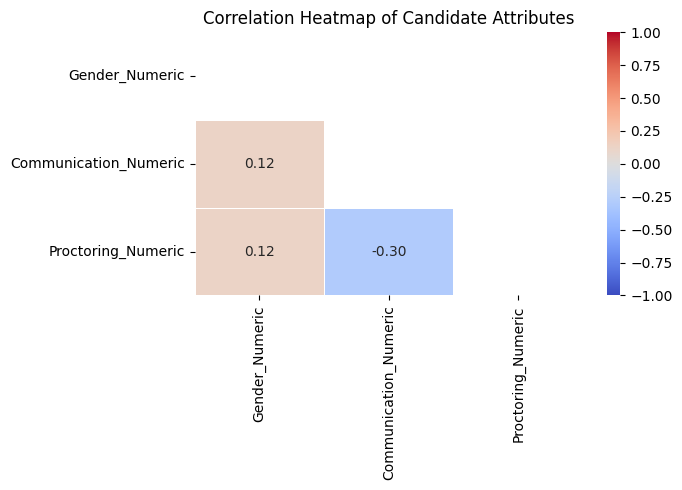

In [25]:


# Create a correlation heatmap for the specified columns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Prepare the data for correlation analysis
# First, ensure all columns are in the right format
corr_data = top_candidates_interviewed.copy()

# Convert gender to numeric (1 for Male, 0 for Female)
if 'Gender' in corr_data.columns:
    corr_data['Gender_Numeric'] = corr_data['Gender'].map({'Male': 1, 'Female': 0})

# Convert communication levels to numeric values
if 'Communication' in corr_data.columns:
    comm_mapping = {
        'C1 (Excellent)': 5, 
        'B2 (Good)': 4, 
        'B1 (Intermediate)': 3, 
        'A2 (Basic)': 2, 
        'A1 (Beginner)': 1
    }
    corr_data['Communication_Numeric'] = corr_data['Communication'].map(comm_mapping)

# Convert Proctoring to numeric by removing % sign
if 'Proctoring' in corr_data.columns:
    corr_data['Proctoring_Numeric'] = corr_data['Proctoring'].str.rstrip('%').astype(float)

# Select columns for correlation based on the specified requirements
columns_to_correlate = []
for col in ['years_of_exp', 'is_passed', 'age', 'Gender_Numeric', 'Communication_Numeric', 'Proctoring_Numeric']:
    if col in corr_data.columns:
        columns_to_correlate.append(col)

# Calculate correlation matrix
correlation_matrix = corr_data[columns_to_correlate].corr()

# Create the heatmap with smaller figure size
plt.figure(figsize=(7, 5))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f', 
            linewidths=0.5,
            mask=mask,
            vmin=-1, 
            vmax=1)
plt.title('Correlation Heatmap of Candidate Attributes')
plt.tight_layout()
plt.show()


In [26]:
AI_applicants_df
manual_screening_applicants_df
top_candidates_interviewed
# Merge all three datasets using email_id as the key
# Using outer merge to ensure we don't lose any rows

# First merge AI_applicants_df with manual_screening_applicants_df
merged_df = pd.merge(
    AI_applicants_df,
    manual_screening_applicants_df,
    on='email_id',
    how='outer',
    suffixes=('_ai', '_manual')
)

# Then merge the result with top_candidates_interviewed
final_merged_df = pd.merge(
    merged_df,
    top_candidates_interviewed,
    on='email_id',
    how='outer',
    suffixes=('', '_interview')
)

# Check the shape of the original and merged dataframes
print(f"AI_applicants_df shape: {AI_applicants_df.shape}")
print(f"manual_screening_applicants_df shape: {manual_screening_applicants_df.shape}")
print(f"top_candidates_interviewed shape: {top_candidates_interviewed.shape}")
print(f"Final merged dataframe shape: {final_merged_df.shape}")

# Display the first few rows of the merged dataframe
final_merged_df


AI_applicants_df shape: (25543, 18)
manual_screening_applicants_df shape: (8960, 19)
top_candidates_interviewed shape: (67, 21)
Final merged dataframe shape: (34509, 56)


,first_name_ai,last_name_ai,email_id,_client_job_id_ai,country_code_ai,job_application_id_ai,years_of_exp_ai,is_completed_ai,vetting_creation_date_ai,vetting_completed_date_ai,...,Column 20,Column 19,Country,React,JavaScript,"HTML,CSS",Coding Exercise,Communication,Proctoring,Experience
0,Lyuben,Tenekedzhiev,lyuben.tenekedjiev@gmail.com,7ab84d91-00ca-460f-ac82-ccad63fb306c,AE,2b85d400-3fd9-4747-af25-314bfdd9220c,4.7,1.0,2025-01-31 14:48:27,2025-01-31 15:31:05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Nils,Schönwald,jobs@schoen.world,7ab84d91-00ca-460f-ac82-ccad63fb306c,DE,009ebd42-bb46-4666-a0a1-0c988b6adcaf,13.1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Adrian,SAFKO,adrian.safko@hotovo.com,7ab84d91-00ca-460f-ac82-ccad63fb306c,SK,cce06f38-ac85-4214-b615-ef98266e8111,14.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Jerold,Twum Adjei-Ampofo,jjaampofo@yahoo.co.uk,7ab84d91-00ca-460f-ac82-ccad63fb306c,AE,9fd030ba-6411-425d-b1b3-00f43bccca63,10.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Helia,Valizadeh,heliiavalizadeh@gmail.com,7ab84d91-00ca-460f-ac82-ccad63fb306c,DE,b539f958-3563-4979-9911-4bdadc6168eb,3.8,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34504,NaN,NaN,heerak.jhp@gmail.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Experienced,Experienced,Experienced,Senior,B2 (Good),68%,4.0
34505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Poland,Experienced,Junior,Junior,Junior,B2 (Good),78%,5.0
34506,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,India,Experienced,Junior,Junior,Senior,B2 (Good),74%,2.0
34507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0


In [27]:
# Count the number of unique email_id in final_merged_df
unique_email_count = final_merged_df['email_id'].nunique()
print(f"Number of unique email_id in final_merged_df: {unique_email_count}")


Number of unique email_id in final_merged_df: 34504


In [28]:

# check to see how many of the emails in the top candidates dataset are in the AI and manual datasets
top_candidates_interviewed['email_id'].isin(AI_applicants_df['email_id']).sum()
# top_candidates_interviewed['email_id'].isin(manual_screening_applicants_df['email_id']).sum()





27

In [39]:
top_candidates_interviewed = pd.read_csv('/Users/nimayazdani/Desktop/AI-Recruiter/micro1-controll-experiment-EDA/top_candidates_interviewed.csv')

# Get all the rows of top_candidates_interviewed where the Result is neither Pass nor Fail
filtered_candidates = top_candidates_interviewed[
    ~(top_candidates_interviewed['Result'].isin(['Pass', 'Fail']))
]

# Display the count and the filtered results
print(f"Number of candidates with Result neither Pass nor Fail: {len(filtered_candidates)}")
display(filtered_candidates)

# Check unique values in the Result column to understand what other values exist
print("\nUnique values in the Result column:")
display(top_candidates_interviewed['Result'].unique())












Number of candidates with Result neither Pass nor Fail: 6


,Name,email_id,Profile link/Interview Link,Interview Type,Interview Date,interviewer,Result,Feedback,Tech interview link,Gender,...,Column 20,Column 19,Country,React,JavaScript,"HTML,CSS",Coding Exercise,Communication,Proctoring,Experience
11,Eugene Kolesnyk,NaN,https://www.client.micro1.ai/ai-interview-repo...,AI + Human Interview,NaN,NaN,NaN,NaN,NaN,Male,...,NaN,NaN,Poland,Experienced,Junior,Junior,Junior,B2 (Good),78%,5.0
13,Shubham,NaN,https://www.client.micro1.ai/ai-interview-repo...,AI + Human Interview,NaN,NaN,NaN,NaN,NaN,Male,...,NaN,NaN,India,Experienced,Junior,Junior,Senior,B2 (Good),74%,2.0
14,Ashwini Kumar,NaN,https://www.client.micro1.ai/ai-interview-repo...,AI + Human Interview,1/28/2025,Swapnil,NaN,NaN,NaN,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
16,Siddesh Thorat,NaN,https://www.client.micro1.ai/ai-interview-repo...,AI + Human Interview,1/28/2025,Sajeed,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
49,Vivekanand ray,vivekanandray3@gmail.com,https://www.client.micro1.ai/candidate/4a40c74...,only Human interview,1/31/2025,Swapnil,Not Joined,NaN,NaN,Male,...,2015.0,32.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52,Shantanu soam,shatanu.singh.soam@gmail.com,https://www.client.micro1.ai/candidate/cb1396a...,only Human interview,1/31/2025,Sajeed,Not Joined,NaN,NaN,Male,...,2021.0,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Unique values in the Result column:


array(['Fail', 'Pass', nan, 'Not Joined'], dtype=object)

In [40]:
top_candidates_interviewed.shape[0]







85